# Engine Condition Prediction — Main Analysis
Binary classification of engine condition from 6 sensor readings. Pipeline: audit → preprocess → baselines → MLP → augmentation ablation → evaluation → interpretation. See `PROJECT_PLAN.md` for full rationale.

## Setup
Imports and adds `../src` to the path to reuse the pipeline modules directly.

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
from IPython.display import Image, display

from preprocess import prepare_data, load_data, FEATURE_COLS, TARGET_COL
from baselines import train_full_baseline, train_rpm_only_baseline
from train import train_model
from evaluate import (
    evaluate_predictions, mlp_probs, permutation_importance_mlp,
    rpm_band_accuracy, plot_confusion_matrices, plot_roc_curves,
    plot_training_curves, plot_permutation_importance, RPM_IDX,
)

%matplotlib inline

## 1. Data Audit
Shape, missing values, duplicates, class balance, and feature–label correlations (PROJECT_PLAN.md §2.1).

In [2]:
df = load_data('../data/engine_data.csv')
print(df.shape, '| duplicates:', df.duplicated().sum())
print(df.isnull().sum().to_dict())
print(df[TARGET_COL].value_counts(normalize=True))
df.corr(numeric_only=True)[TARGET_COL].sort_values()

(19535, 7) | duplicates: 0
{'Engine rpm': 0, 'Lub oil pressure': 0, 'Fuel pressure': 0, 'Coolant pressure': 0, 'lub oil temp': 0, 'Coolant temp': 0, 'Engine Condition': 0}
Engine Condition
1    0.630509
0    0.369491
Name: proportion, dtype: float64


Engine rpm         -0.268201
lub oil temp       -0.093635
Coolant temp       -0.046326
Coolant pressure   -0.024054
Lub oil pressure    0.060904
Fuel pressure       0.116259
Engine Condition    1.000000
Name: Engine Condition, dtype: float64

## 2. Preprocessing
Stratified 70/15/15 split, train-only `StandardScaler`, and `pos_weight` for the 63/37 class imbalance (PROJECT_PLAN.md §3).

In [3]:
data = prepare_data('../data/engine_data.csv')
X_train, X_val, X_test = data['X_train'], data['X_val'], data['X_test']
y_train, y_val, y_test = data['y_train'], data['y_val'], data['y_test']
pos_weight, scaler = data['pos_weight'], data['scaler']

print(f"Train/Val/Test sizes: {X_train.shape[0]}/{X_val.shape[0]}/{X_test.shape[0]}")
print(f"pos_weight: {pos_weight.item():.3f}")

Train/Val/Test sizes: 13674/2930/2931
pos_weight: 0.586


## 3. Baselines — Logistic Regression
Full-feature and RPM-only linear baselines, class-weighted, establishing the bar the MLP needs to clear (PROJECT_PLAN.md §4).

In [4]:
lr_full = train_full_baseline(X_train, y_train)
lr_rpm = train_rpm_only_baseline(X_train, y_train, rpm_col_idx=RPM_IDX)

res_lr_full = evaluate_predictions(y_test, lr_full.predict_proba(X_test)[:, 1])
res_lr_rpm = evaluate_predictions(y_test, lr_rpm.predict_proba(X_test[:, [RPM_IDX]])[:, 1])

print(f"LR (full):     AUC={res_lr_full['roc_auc']:.3f}")
print(f"LR (rpm only): AUC={res_lr_rpm['roc_auc']:.3f}")

LR (full):     AUC=0.696
LR (rpm only): AUC=0.669


## 4. MLP Training
6→32→16→8→1 MLP, `BCEWithLogitsLoss(pos_weight)`, Adam, early stopping on val loss (PROJECT_PLAN.md §5).

In [5]:
mlp_plain, hist_plain = train_model(
    X_train, y_train, X_val, y_val, pos_weight, use_augmentation=False
)
res_mlp_plain = evaluate_predictions(y_test, mlp_probs(mlp_plain, X_test))

print(f"Epochs trained: {len(hist_plain['train_loss'])}")
print(f"MLP (no aug): AUC={res_mlp_plain['roc_auc']:.3f}")

Epochs trained: 39
MLP (no aug): AUC=0.700


## 5. Augmentation Ablation
Gaussian jitter (σ=0.05, train-only, per-batch) as a regularizer, compared against the unaugmented MLP (PROJECT_PLAN.md §3, §5.5).

In [6]:
mlp_aug, hist_aug = train_model(
    X_train, y_train, X_val, y_val, pos_weight, use_augmentation=True
)
res_mlp_aug = evaluate_predictions(y_test, mlp_probs(mlp_aug, X_test))

print(f"MLP (with aug): AUC={res_mlp_aug['roc_auc']:.3f}  (vs {res_mlp_plain['roc_auc']:.3f} without)")

MLP (with aug): AUC=0.698  (vs 0.700 without)


## 6. Evaluation — Comparison Table
Accuracy, AUC, and per-class recall/F1 for all four models (PROJECT_PLAN.md §6).

In [7]:
results = {
    'LR (full)': res_lr_full,
    'LR (rpm only)': res_lr_rpm,
    'MLP (no aug)': res_mlp_plain,
    'MLP (with aug)': res_mlp_aug,
}
pd.DataFrame({name: {
    'AUC': r['roc_auc'], 'Accuracy': r['accuracy'],
    'Recall(0)': r['recall']['class_0'], 'Recall(1)': r['recall']['class_1'],
    'F1(0)': r['f1']['class_0'], 'F1(1)': r['f1']['class_1'],
} for name, r in results.items()}).T.round(3)

,AUC,Accuracy,Recall(0),Recall(1),F1(0),F1(1)
LR (full),0.696,0.651,0.605,0.678,0.562,0.710
LR (rpm only),0.669,0.636,0.571,0.674,0.537,0.700
MLP (no aug),0.700,0.636,0.729,0.581,0.597,0.668
MLP (with aug),0.698,0.628,0.729,0.568,0.592,0.658


## 7. Evaluation — Plots
Confusion matrices, ROC curves, and training curves (also saved to `outputs/figures/`).

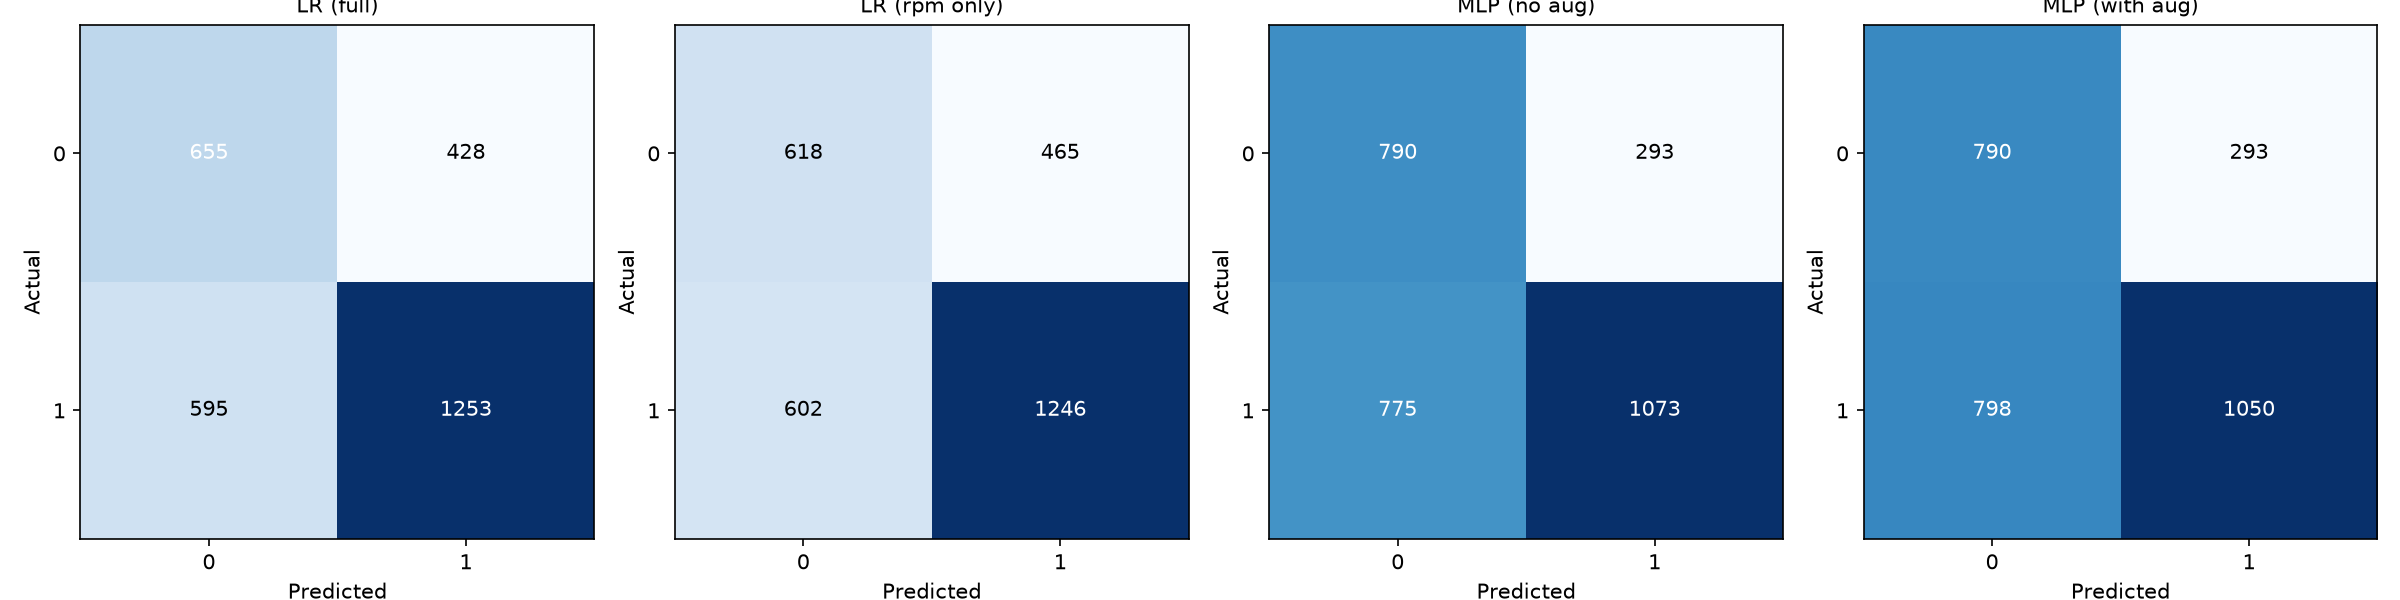

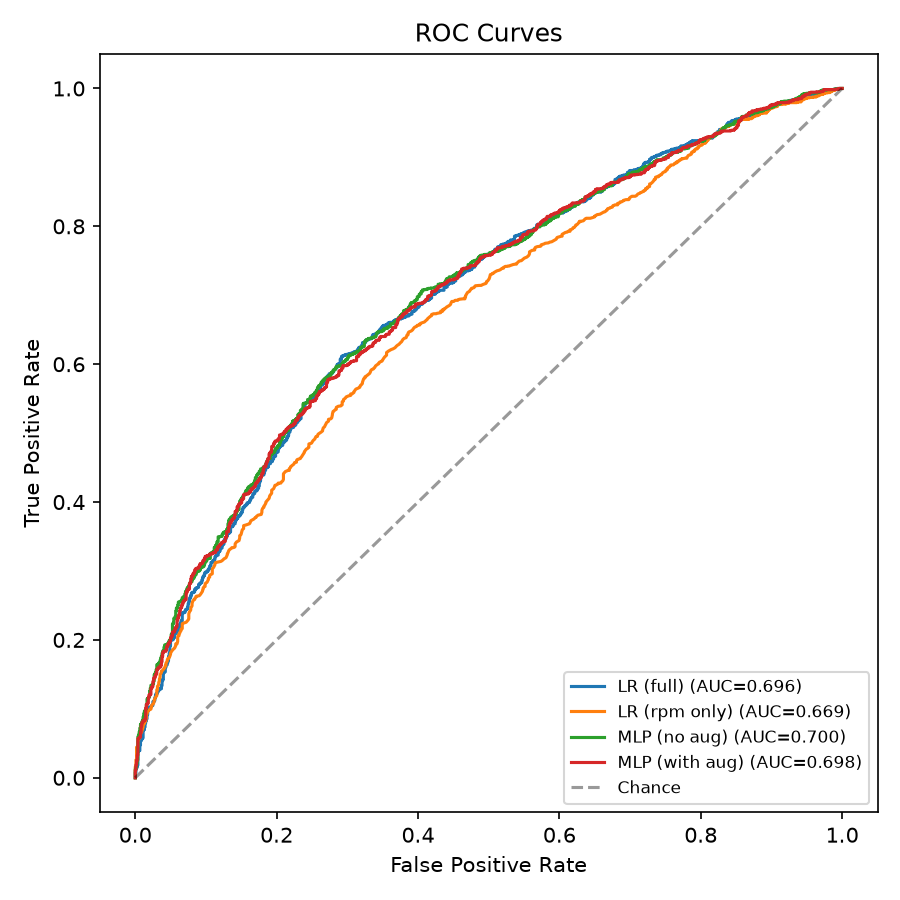

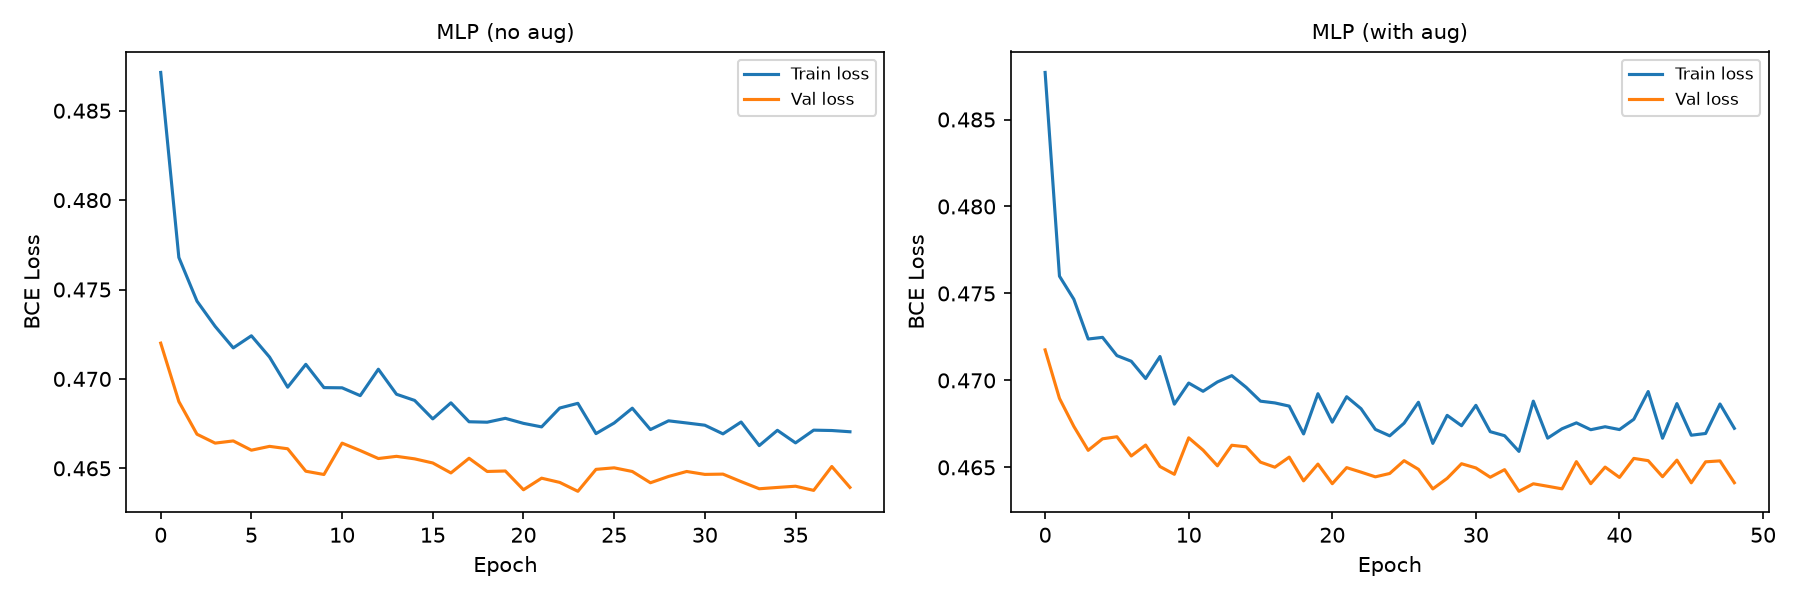

In [8]:
plot_confusion_matrices(results, '../outputs/figures/confusion_matrices.png')
plot_roc_curves(y_test, results, '../outputs/figures/roc_curves.png')
plot_training_curves(
    {'MLP (no aug)': hist_plain, 'MLP (with aug)': hist_aug},
    '../outputs/figures/training_curves.png',
)

display(Image('../outputs/figures/confusion_matrices.png'))
display(Image('../outputs/figures/roc_curves.png'))
display(Image('../outputs/figures/training_curves.png'))

## 8. Interpretation — Permutation Importance
Mean AUC drop per feature when shuffled, on the unaugmented MLP (PROJECT_PLAN.md §7.4).

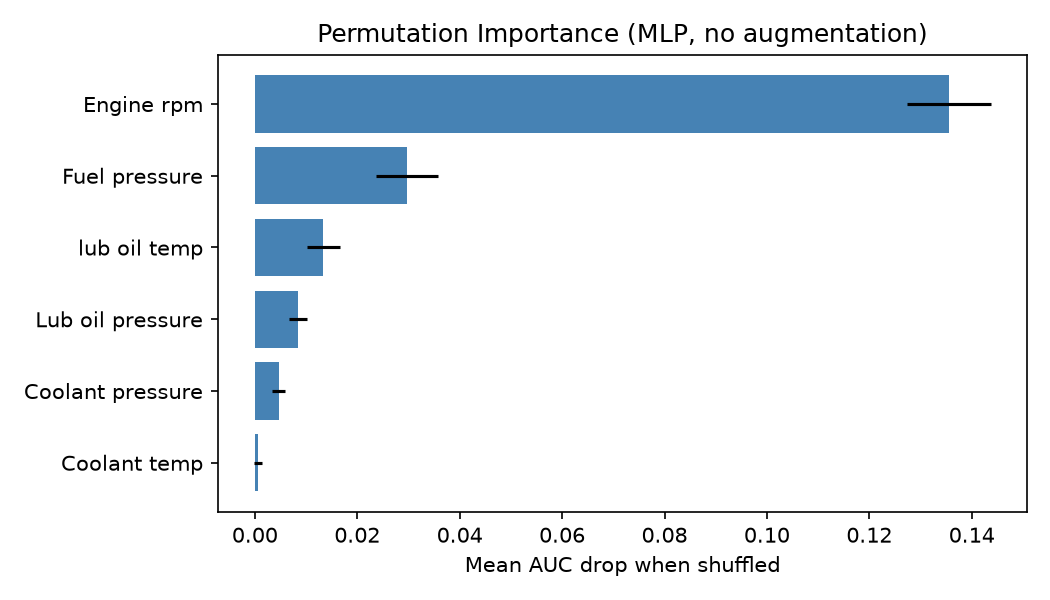

,mean,std
Engine rpm,0.1355,0.0082
Fuel pressure,0.0297,0.0060
lub oil temp,0.0133,0.0032
Lub oil pressure,0.0084,0.0017
Coolant pressure,0.0047,0.0013
Coolant temp,0.0007,0.0008


In [9]:
importances = permutation_importance_mlp(mlp_plain, X_test, y_test, res_mlp_plain['roc_auc'])
plot_permutation_importance(importances, '../outputs/figures/permutation_importance.png')
display(Image('../outputs/figures/permutation_importance.png'))

pd.DataFrame(importances).T.round(4).sort_values('mean', ascending=False)

## 9. Interpretation — RPM-Band Failure Case
MLP accuracy by `Engine rpm` quartile — the failure mode behind the dominant feature (PROJECT_PLAN.md §7.4).

In [10]:
bands = rpm_band_accuracy(mlp_plain, X_test, y_test, scaler)
pd.DataFrame(bands)

,band,rpm_range,n,accuracy
0,Q1,"[77.0, 591.0]",729,0.790123
1,Q2,"[591.0, 748.0]",736,0.663043
2,Q3,"[748.0, 943.0]",732,0.545082
3,Q4,"[943.0, 2191.0]",734,0.544959


## 10. Conclusion
- AUC ≈ 0.70 ceiling holds across logistic regression, random forest, gradient boosting, and MLP (with and without engineered features) — a data information ceiling, not a modeling limitation.
- Augmentation is a negative result here: dropout + batchnorm + weight decay already sufficiently regularize this 993-parameter model on 13.6k training rows.
- `Engine rpm` dominates permutation importance (~4x the next feature) and drives the accuracy drop at high RPM.
- `Engine Condition` label semantics (0 vs. 1 = healthy) are undocumented — metrics are reported per class rather than assuming a direction.